<a href="https://colab.research.google.com/github/fea-dev-usp/Curso-de-Python-FEA.dev/blob/main/Materias%20das%20Aulas/Aula%205%20e%20Aula%206/aula6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>

> Ao rodar no Colab, faça o upload do arquivo `PIB dos Municipios.xlsx` para a sessão antes de executar as células.

# Aula 6 - Manipulação de Dados com Pandas

Nessa aula, vamos aprender sobre as principais formas de **manipular dados no pandas e plotagens no matplotlib e seaborn** no Python.

Faremos com o mesmo dataset da última aula e/ou com exemplos mais simples.

---

### Estrutura da aula

- **6.1 Fundamentos de Limpeza de Dados**
    - 6.1.1 Tratamento de valores ausentes: `isna()`, `dropna()`, `fillna()`, `ffill()`, `bfill()`
    - 6.1.2 Tipagem e formatação: `astype()`, `to_datetime()`, `replace()` 
- **6.2 Filtragem e Operações Booleanas**
    - 6.2.1 Filtros condicionais com operadores booleanos
- **6.3 GroupBy e Agg (Abstração de Agregação)**
    - 6.3.1 `groupby()` por um ou múltiplas colunas
    - 6.3.2 `agg()` com métricas simultâneas
    - 6.3.3 Verificação de Pertencimento com `isin()`
- **6.4 Concatenação e Integração de DataFrames**
    - 6.4.1 `concat()`
    - 6.4.2 `merge()`: inner, left, right, outer
    - 6.4.3 `join()`: inner, left, right, outer 
- **6.5 Análise Estatística e Métodos de Análise Temporal**
    - 6.5.1 `sum()`, `mean()`, `count()`, `std()`, `where()` e integração vetorial com NumPy
    - 6.5.2 Matriz de correlação com `corr()`
    - 6.5.3 `diff()`, `pct_change()`
- **6.6 Vizualização**
    - 6.6.1 `plot()`, `hist()`, `scatter()`
    - 6.6.2 Matplotlib
    - 6.6.3 Seaborn


---

In [157]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
cidades = pd.read_excel('PIB dos Municipios.xlsx', sheet_name='Cidades')


In [166]:

cidades.rename(columns={'Produto Interno Bruto, \na preços correntes\n(R$ 1.000)': "PIB", "Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)":'PIB_na'}, inplace=True)

In [160]:
print("Colunas do dataset:")

print(cidades.columns.tolist())
print("\nPrimeiras linhas:")
print(cidades.head())


Colunas do dataset:
['Ano', 'Nome da Grande Região', 'Código da Unidade da Federação', 'Sigla da Unidade da Federação', 'Nome da Unidade da Federação', 'Nome do Município', 'Nome da Mesorregião', 'Nome da Microrregião', 'Nome da Região Geográfica Imediata', 'Nome da Região Geográfica Intermediária', 'Hierarquia Urbana (principais categorias)', 'Nome da Região Rural', 'Região rural (segundo classificação do núcleo)', 'Amazônia Legal', 'Semiárido', 'Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)', 'Valor adicionado bruto da Indústria,\na preços correntes\n(R$ 1.000)', 'Valor adicionado bruto dos Serviços,\na preços correntes \n- exceto Administração, defesa, educação e saúde públicas e seguridade social\n(R$ 1.000)', 'Valor adicionado bruto da Administração, defesa, educação e saúde públicas e seguridade social, \na preços correntes\n(R$ 1.000)', 'Valor adicionado bruto total, \na preços correntes\n(R$ 1.000)', 'Impostos, líquidos de subsídios, sobre produtos, \

## Fundamentos de Limpeza de Dados

### Tratamento de Valores Ausentes

### `isna()`

- Identificar valores nulos, dando apenas um diagnóstico

In [167]:
# Verificar valores nulos em cada coluna
print("Número de valores nulos por coluna:")
print(cidades.isna().sum()[cidades.isna().sum()>0])

# Verificar se há valores nulos em qualquer coluna
print("\nColunas com valores nulos:")
print(cidades.isnull().any()[cidades.isnull().any()==True])

# Informações gerais sobre o DataFrame, incluindo tipos e nulos
print("\nInformações do DataFrame:")
cidades.info()

Número de valores nulos por coluna:
PIB_na                                                                                                                                                  11140
Valor adicionado bruto da Indústria,\na preços correntes\n(R$ 1.000)                                                                                    11140
Valor adicionado bruto dos Serviços,\na preços correntes \n- exceto Administração, defesa, educação e saúde públicas e seguridade social\n(R$ 1.000)    11140
Valor adicionado bruto da Administração, defesa, educação e saúde públicas e seguridade social, \na preços correntes\n(R$ 1.000)                        11140
Valor adicionado bruto total, \na preços correntes\n(R$ 1.000)                                                                                          11140
Impostos, líquidos de subsídios, sobre produtos, \na preços correntes\n(R$ 1.000)                                                                       11140
Atividade com ma

### `dropna()`

- Remove linhas ou colunas com valores nulos

In [162]:
# Remover linhas com qualquer valor nulo
# cidades_sem_nulos = cidades.dropna()
print("DataFrame original:", cidades.shape)
# print("DataFrame após dropna():", cidades_sem_nulos.shape)

# Remover apenas linhas onde PIB ou População são nulos
# cidades_clean = cidades.dropna(subset=['Valor adicionado bruto total, \na preços correntes\n(R$ 1.000)', 'PIB'])
# print("DataFrame após dropna() em colunas específicas:", cidades_clean.shape)

DataFrame original: (77965, 26)


### `fillna()`

- Preenche o valor nulo com um valor específico

In [169]:
# Preencher valores nulos na coluna PIB com 0
cidades['PIB_fillna'] = cidades['PIB_na'].fillna(0)
print("Soma dos valores do PIB após fillna(0):", cidades['PIB_fillna'].sum())
print("Soma dos valores do PIB antes:", cidades['PIB_na'].sum())

# Preencher com a mediana da coluna
mediana_pib = cidades['PIB_na'].median()
cidades['PIB_fill_mediana'] = cidades['PIB_na'].fillna(mediana_pib)
print("Mediana do PIB:", mediana_pib)
print("Soma dos valores do PIB  após fill com mediana:", cidades['PIB_fill_mediana'].sum())

Soma dos valores do PIB após fillna(0): 3555539999.9100003
Soma dos valores do PIB antes: 3555539999.9100003
Mediana do PIB: 23760.519
Soma dos valores do PIB  após fill com mediana: 3820232181.5700006


In [170]:
mediana_pib = cidades['PIB_na'].median()
mediana_pib_na = cidades['PIB_fillna'].median()
mediana_pib - mediana_pib_na

np.float64(5686.373)

### `ffill()`

- Preenche o valor nulo com o valor anterior

In [173]:
# Ordenar por ano e preencher valores nulos com o valor anterior (forward fill)
cidades_sorted = cidades.sort_values('Ano')
cidades_sorted['PIB_ffill'] = cidades_sorted.groupby('Sigla da Unidade da Federação')['PIB_na'].ffill()
print("Valores nulos em PIB após ffill():", cidades_sorted['PIB_ffill'].isna().sum())

# Exemplo simples de ffill em uma coluna
cidades['PIB_ffill'] = cidades['PIB_na'].ffill()
print("Forward fill aplicado na coluna PIB.")

Valores nulos em PIB após ffill(): 0
Forward fill aplicado na coluna PIB.


### `bfill()`

- Preenche o valor nulo com o valor posterior

In [ ]:
# Preencher valores nulos com o valor posterior (backward fill)
cidades['PIB_bfill'] = cidades.groupby('Sigla da Unidade da Federação')['PIB'].bfill()
print("Valores nulos em PIB após bfill():", cidades['PIB'].isna().sum())

# Exemplo simples de bfill
cidades['PIB_bfill'] = cidades['PIB'].bfill()
print("Backward fill aplicado na coluna Populacao.")

In [ ]:
cidades['PIB_interpolado'] = cidades['PIB_na'].interpolate()

---

### Tipagem e Formatação: `Astype()`, `replace()`

#### `Astype()`

In [177]:
cidades['Amazônia Legal'] = cidades['Amazônia Legal'].astype(bool)

print(cidades.dtypes)

Ano                                                                                                                                                       int64
Nome da Grande Região                                                                                                                                       str
Código da Unidade da Federação                                                                                                                            int64
Sigla da Unidade da Federação                                                                                                                               str
Nome da Unidade da Federação                                                                                                                                str
Nome do Município                                                                                                                                           str
Nome da Mesorregião                     

#### `to_datetime()`

#### `replace()`

In [178]:
#cidades['Amazônia Legal'] = cidades['Amazônia Legal'].str.replace('Sim', 'True').str.replace('Não', 'False').astype(bool)

cidades['Semiárido'] = cidades['Semiárido'].str.replace('Sim', 'True').str.replace('Não', 'False').astype(bool)

print(cidades['Semiárido'].dtypes)

bool


---

## Filtragem e Operações Booleanas

### Filtros Condicionais com Operadores Booleanos

- And:`&` no pandas; seleciona linhas que **satisfazem todas as condições**
- Or: `|` no pandas; seleciona linhas que **satisfazem pelo menos uma condição**
- Not `~` no pandas; selciona linhas que **invertem a condição**

### Métodos Básicos de Agregação

### `groupby()` Por Uma ou Múltiplas Colunas

- Usado para agrupar dados por uma ou mais colunas para aplicar operações (média, soma, etc)

In [180]:
pd.set_option('display.float_format', '{:.2f}'.format)

# Agrupar por UF e calcular soma do PIB
estado_pib = cidades.groupby('Sigla da Unidade da Federação')['PIB'].sum()
print("Soma do PIB por UF:")
print(estado_pib.head())

# Agrupar por Região e calcular média do PIB
regiao_pib = cidades.groupby('Nome da Grande Região')['PIB'].mean()
print("\nMédia do PIB por Região:")
print(regiao_pib)

# Agrupamento múltiplo: por Região e UF
multi_group = cidades.groupby(['Nome da Grande Região', 'Sigla da Unidade da Federação'])['PIB'].sum()
print("\nSoma do PIB por Região e UF:")
print(multi_group['Sudeste'])

Soma do PIB por UF:
Sigla da Unidade da Federação
AC    212791731.96
AL    738984780.00
AM   1405198203.18
AP    223122241.47
BA   3775929052.11
Name: PIB, dtype: float64

Média do PIB por Região:
Nome da Grande Região
Centro-oeste   1450544.59
Nordeste        528164.34
Norte           856774.50
Sudeste        2183291.57
Sul             957225.88
Name: PIB, dtype: float64

Soma do PIB por Região e UF:
Sigla da Unidade da Federação
ES    1888751954.62
MG    8524523103.47
RJ   10376254762.23
SP   30194694933.51
Name: PIB, dtype: float64


### `agg()` com Métricas Simultâneas

- Permite calcular vparias estatísticas ao mesmo tempo

In [181]:
# Calcular múltiplas estatísticas simultaneamente por Região
stats_por_regiao = cidades.groupby('Nome da Grande Região').agg({
    'PIB': ['sum', 'mean', 'std', 'min', 'max'],
    'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)': ['mean']
})
print("Estatísticas por Região:")
print(stats_por_regiao)

Estatísticas por Região:
                                 PIB                                   \
                                 sum       mean         std       min   
Nome da Grande Região                                                   
Centro-oeste           9479308904.91 1450544.59 11741971.34  11491.45   
Nordeste              13265375524.48  528164.34  2887810.21 -19046.43   
Norte                  5395109009.13  856774.50  4507370.84  11116.65   
Sudeste               50984224753.82 2183291.57 20136222.93   9627.53   
Sul                   15952169361.23  957225.88  4119552.63  15630.24   

                                     \
                                max   
Nome da Grande Região                 
Centro-oeste           365669107.91   
Nordeste                86939831.74   
Norte                  127649795.49   
Sudeste               1066825104.98   
Sul                    120065276.02   

                      Produto Interno Bruto per capita, \na preços correntes\

In [182]:
cidades.nsmallest(7, 'PIB')

,Ano,Nome da Grande Região,Código da Unidade da Federação,Sigla da Unidade da Federação,Nome da Unidade da Federação,Nome do Município,Nome da Mesorregião,Nome da Microrregião,Nome da Região Geográfica Imediata,Nome da Região Geográfica Intermediária,...,"Valor adicionado bruto total, \na preços correntes\n(R$ 1.000)","Impostos, líquidos de subsídios, sobre produtos, \na preços correntes\n(R$ 1.000)",PIB,"Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)",Atividade com maior valor adicionado bruto,Atividade com segundo maior valor adicionado bruto,Atividade com terceiro maior valor adicionado bruto,PIB_fillna,PIB_fill_mediana,PIB_ffill
12253,2012,Nordeste,24,RN,Rio Grande do Norte,Guamaré,Central Potiguar,Macau,Açu,Mossoró,...,-92078.04,73031.61,-19046.43,-1459.83,Demais serviços,"Administração, defesa, educação e saúde públic...",Comércio e reparação de veículos automotores e...,17191.31,17191.31,17191.31
17819,2013,Nordeste,24,RN,Rio Grande do Norte,Guamaré,Central Potiguar,Macau,Açu,Mossoró,...,-67393.88,71592.82,4198.94,301.60,Demais serviços,"Administração, defesa, educação e saúde públic...",Comércio e reparação de veículos automotores e...,21746.07,21746.07,21746.07
847,2010,Nordeste,22,PI,Piauí,Santo Antônio dos Milagres,Centro-Norte Piauiense,Médio Parnaíba Piauiense,Amarante - Água Branca - Regeneração,Teresina,...,7022.40,195.36,7217.77,3507.17,"Administração, defesa, educação e saúde públic...",Demais serviços,Construção,195.99,195.99,195.99
793,2010,Nordeste,22,PI,Piauí,Miguel Leão,Centro-Norte Piauiense,Teresina,Amarante - Água Branca - Regeneração,Teresina,...,7079.34,292.07,7371.41,5883.01,"Administração, defesa, educação e saúde públic...",Demais serviços,"Agricultura, inclusive apoio à agricultura e a...",901.82,901.82,901.82
6358,2011,Nordeste,22,PI,Piauí,Miguel Leão,Centro-Norte Piauiense,Teresina,Amarante - Água Branca - Regeneração,Teresina,...,7816.79,270.14,8086.92,6495.52,"Administração, defesa, educação e saúde públic...",Demais serviços,"Agricultura, inclusive apoio à agricultura e a...",1291.63,1291.63,1291.63
866,2010,Nordeste,22,PI,Piauí,São Luis do Piauí,Sudeste Piauiense,Picos,Picos,Picos,...,8269.25,289.87,8559.13,3342.10,"Administração, defesa, educação e saúde públic...",Demais serviços,"Pecuária, inclusive apoio à pecuária",541.78,541.78,541.78
867,2010,Nordeste,22,PI,Piauí,São Miguel da Baixa Grande,Centro-Norte Piauiense,Valença do Piauí,Amarante - Água Branca - Regeneração,Teresina,...,8441.70,457.78,8899.48,4211.77,"Administração, defesa, educação e saúde públic...",Demais serviços,"Pecuária, inclusive apoio à pecuária",583.60,583.60,583.60


### Verificação de Pertencimento com `isin()`

- Método verifica se os valores de uma coluna pertencem a uma lista de valores


In [ ]:
# Filtrar municípios das regiões Nordeste e Sudeste
nordeste_sudeste = cidades[cidades['Nome da Grande Região'].isin(['Nordeste', 'Sudeste'])]
print("Número de municípios em Nordeste e Sudeste:", len(nordeste_sudeste[nordeste_sudeste['Ano'] == 2010]))

# Filtrar UFs específicas
estados_selecionados = cidades[cidades['Sigla da Unidade da Federação'].isin(['SP', 'RJ', 'MG'])]
print("Número de municípios em SP, RJ, MG:", len(estados_selecionados[estados_selecionados['Ano'] == 2010]))

Número de municípios em Nordeste e Sudeste: 3462
Número de municípios em SP, RJ, MG: 1590


--- 

## Concatenação e Integração de DataFrames

### `concat()`

- Concatenar dataframes seja pelas linhas (axis=0) e pelas colunas (axis=1)
- Bom para usar datasets de mesmo formato

### `merge()`: inner, left, right, outer

- Join relacional (semelhante ao SQL)
- Inner: mantém apenas as correspondências
- Left: mantém todos da esquerda
- Right: mantém todos da direita
- Outer: mantém todos

### `join()`: inner, left, right, outer

- Forma simplificada de merge usando índice
- Vantajoso quando precisa usar o mesmo índice

---

In [195]:
# Exemplo de concatenação (se houvesse dois datasets por ano)
df_2020 = cidades[cidades['Ano'] == 2020]
df_2021 = cidades[cidades['Ano'] == 2021]
combined = pd.concat([df_2020, df_2021], axis=0, ignore_index=True)
print("DataFrame combinado:", combined.shape)

# Exemplo de merge (inner join)
# Supondo dois DataFrames com colunas em comum
df1 = cidades[['Nome do Município', 'Sigla da Unidade da Federação', 'PIB']].head(10)
df2 = cidades[['Nome do Município', 'Sigla da Unidade da Federação', 'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)']].head(10)
merged = df1.merge(df2, on=['Nome do Município', 'Sigla da Unidade da Federação'], how='inner')
print("Merge inner:")
print(merged.head())

# Exemplo de join (usando índice)
# Definir índice como Município
cidades_indexed = cidades.set_index('Nome do Município')
df_pib = cidades_indexed[['PIB']].head(10)
df_PIBC = cidades_indexed[['Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)']].head(10)
joined = df_pib.join(df_PIBC, how='inner')
print("\nJoin inner:")
print(joined.head())

joined.reset_index(drop=False, inplace=True)
joined

DataFrame combinado: (11140, 29)
Merge inner:
       Nome do Município Sigla da Unidade da Federação        PIB  \
0  Alta Floresta D'Oeste                            RO  262076.88   
1              Ariquemes                            RO 1364693.78   
2                 Cabixi                            RO   69611.11   
3                 Cacoal                            RO 1186494.09   
4             Cerejeiras                            RO  222021.19   

   Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)  
0                                           10731.18                  
1                                           15103.86                  
2                                           11033.62                  
3                                           15095.15                  
4                                           13037.06                  

Join inner:
                             PIB  \
Nome do Município                  
Alta Floresta D'Oeste  26207

,Nome do Município,PIB,"Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)"
0,Alta Floresta D'Oeste,262076.88,10731.18
1,Ariquemes,1364693.78,15103.86
2,Cabixi,69611.11,11033.62
3,Cacoal,1186494.09,15095.15
4,Cerejeiras,222021.19,13037.06
5,Colorado do Oeste,193092.60,10380.21
6,Corumbiara,114768.27,13038.89
7,Costa Marques,107583.05,7852.78
8,Espigão D'Oeste,311787.84,10848.19
9,Guajará-Mirim,598167.05,14363.13


## Análise Estatística e Métodos de Análise Temporal

### `sum()`, `mean()`, `count()`, `std()`

- sum(): soma
- mean(): média
- count(): contagem
- std(): desvio padrão

### Matriz de Correlação com `corr()`

- Calcula a correlação entre colunas numéricas de um DataFrame

### `where()` e Integração com NumPy

- Importante para filtragem de Outliers
- Mantém valores que satisfazem uma condição e substitui os outros
- df.where(condição, outro_valor_se_false) 
- np.where(condição, valor_se_true, valor_se_false)

### `diff()`

- Calcula a diferença absoluta entre um valor e o seu anterior

###  `pct_change()`

- Calcula mudança percentual entre períodos

---

## Vizualização

### `plot()`, `hist()`, `scatter()`

### Matplotlib

- https://matplotlib.org/
- Biblioteca que serve de base para as outras
- Melhor controle sobre os gráficos, mas exige mais linhas de código
- Visual menos moderno, sendo pouco interativo


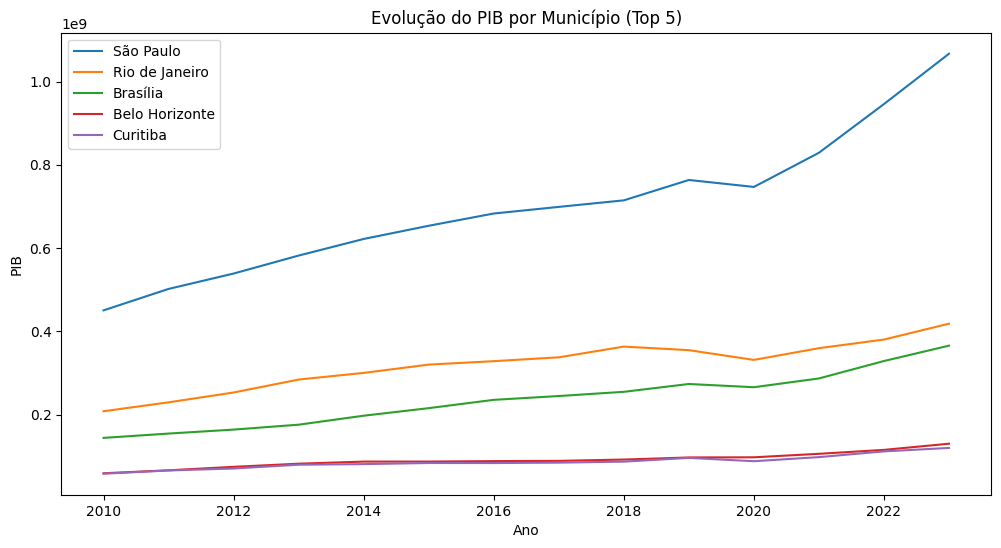

/tmp/ipykernel_5236/990580935.py:15: RuntimeWarning: invalid value encountered in log
  cidades['PIB_log'] = cidades['PIB'].apply(lambda x: np.log(x))


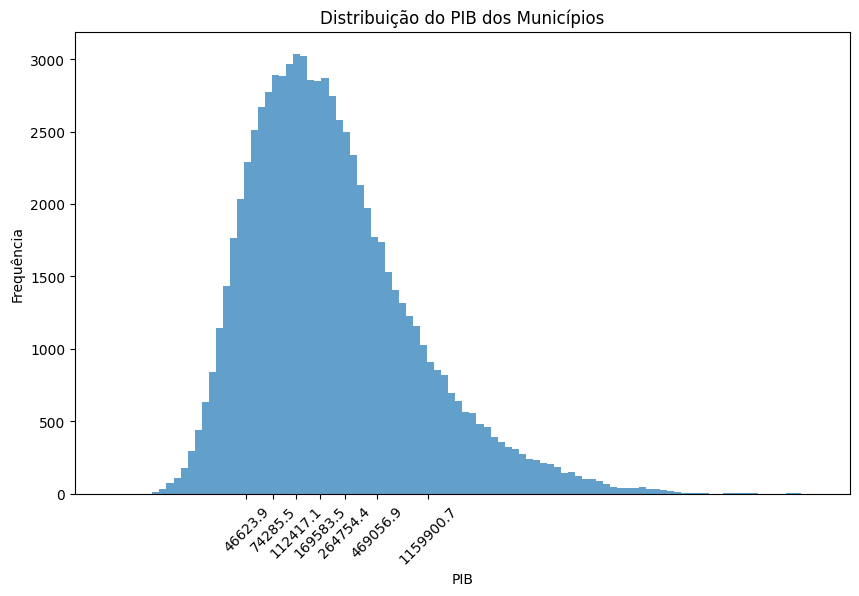

In [200]:
# Gráfico de linha da evolução do PIB por UF (top 5)
fig, ax = plt.subplots(figsize=(12, 6))
cidades_top = cidades.groupby('Nome do Município')['PIB'].median().nlargest(5).index
for um in cidades_top:
    um_data = cidades[cidades['Nome do Município'] == um]
    
    ax.plot(um_data['Ano'], um_data['PIB'], label=um)
ax.set_xlabel('Ano')
ax.set_ylabel('PIB')
ax.set_title('Evolução do PIB por Município (Top 5)')
ax.legend()
plt.show()

# Histograma do PIB
cidades['PIB_log'] = cidades['PIB'].apply(lambda x: np.log(x))
plt.figure(figsize=(10, 6))
plt.hist(cidades['PIB_log'], bins=100, alpha=0.7)

labels = [str(round(label, 1)) for label in cidades['PIB'].quantile([x/8 for x in range(1, 8)])]
plt.xticks(
    np.log(cidades.loc[cidades['PIB'] > 0, 'PIB'].quantile([x/8 for x in range(1, 8)])),
    labels,
    rotation=45
)

plt.xlabel('PIB')
plt.ylabel('Frequência')
plt.title('Distribuição do PIB dos Municípios')
plt.show()


### Seaborn

- https://seaborn.pydata.org/
- Sintaxe mais simples
- Fácil para análise exploratória de dados - usando KDE
- Visual mais moderno

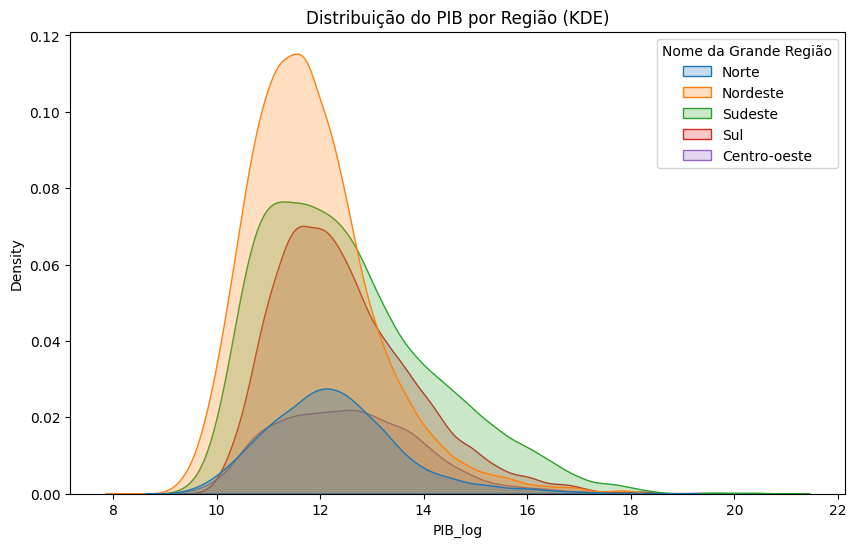

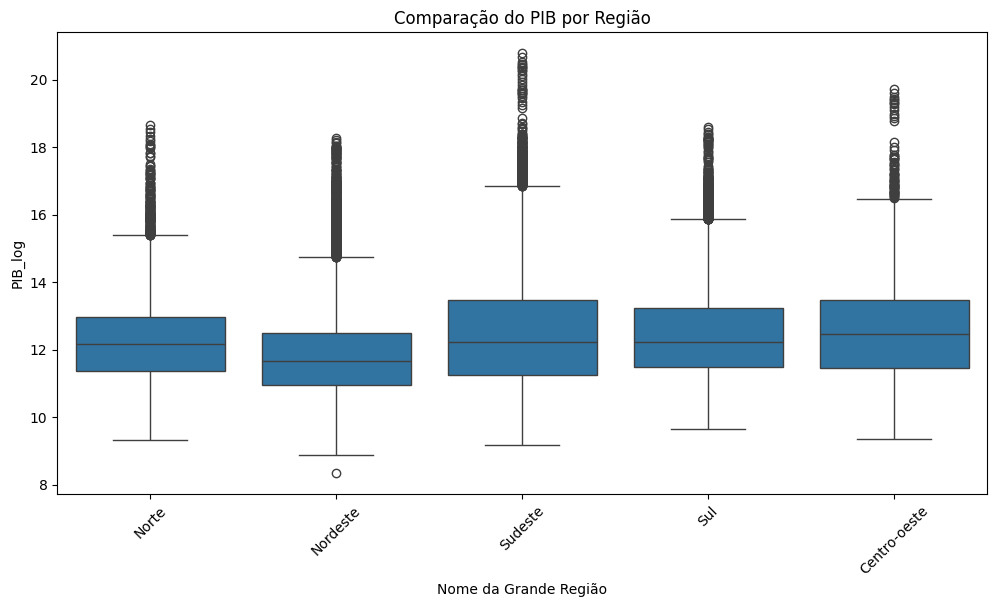

In [201]:
# Gráfico KDE da distribuição do PIB por região
plt.figure(figsize=(10, 6))
sns.kdeplot(data=cidades, x='PIB_log', hue='Nome da Grande Região', fill=True)
plt.title('Distribuição do PIB por Região (KDE)')
plt.show()

# Box plot para comparação do PIB por região
plt.figure(figsize=(12, 6))
sns.boxplot(data=cidades, x='Nome da Grande Região', y='PIB_log')
plt.title('Comparação do PIB por Região')
plt.xticks(rotation=45)
plt.show()
